In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import warnings
warnings.filterwarnings('ignore')

torch.manual_seed(42); np.random.seed(42)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")

Device: cpu


In [3]:
df = pd.read_csv('/content/drive/MyDrive/GEE_exports/nc_coast_final.csv',
                 parse_dates=['timestamp'])
df = df.sort_values('timestamp').reset_index(drop=True)

df['wind_speed'] = np.sqrt(df['u_wind']**2 + df['v_wind']**2)

print(df[['timestamp','wind_speed','temperature_2m','total_precipitation','SST']].head())
df['wind_speed'].describe()

   timestamp  wind_speed  temperature_2m  total_precipitation        SST
0 2020-01-01    3.668797      282.956753         2.145767e-06  15.752083
1 2020-01-02    1.839040      283.567308         8.761882e-07  15.231250
2 2020-01-03    5.017116      290.960683         3.710985e-05  14.840426
3 2020-01-04    5.796443      292.144864         4.783556e-03  15.335417
4 2020-01-05    5.752748      282.884910         2.384269e-04  15.462500


,wind_speed
count,1373.000000
mean,3.049462
std,1.456391
min,0.090320
25%,2.041616
50%,2.885808
75%,3.898648
max,9.415217


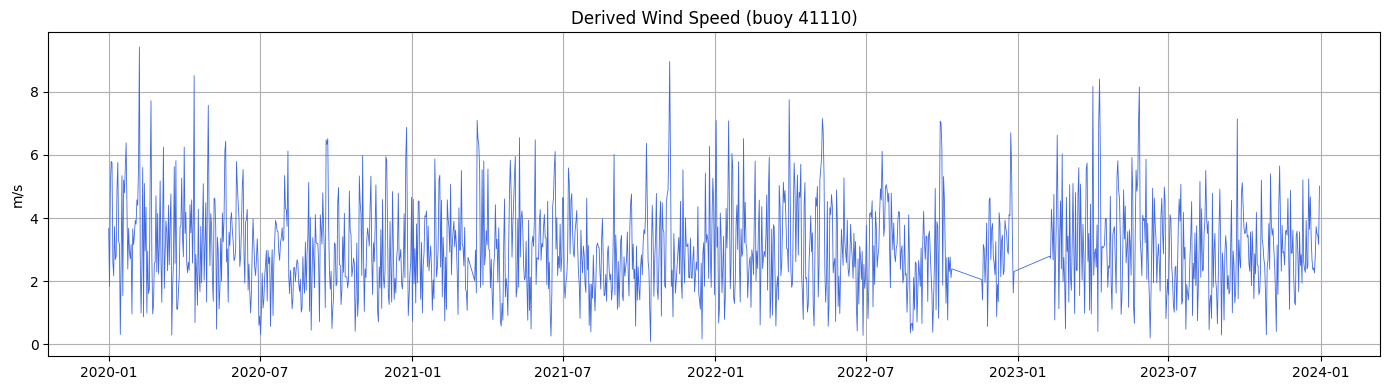

In [4]:
fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(df['timestamp'], df['wind_speed'], lw=0.6, color='royalblue')
ax.set_title('Derived Wind Speed (buoy 41110)'); ax.set_ylabel('m/s'); ax.grid(True)
plt.tight_layout(); plt.show()


In [5]:
window  = 6
batch   = 16
epochs  = 250
lr      = 5e-3
lags    = [1, 2, 3, 5, 6]

In [6]:
for lag in lags:
    df[f'wind_speed_lag{lag}'] = df['wind_speed'].shift(lag)

FEATURE_COLS = ['temperature_2m', 'total_precipitation', 'SST'] + [f'wind_speed_lag{l}' for l in lags]
TARGET_COL   = 'wind_speed'

df_clean = df[FEATURE_COLS + [TARGET_COL]].dropna().reset_index(drop=True)
print(f"Clean samples : {len(df_clean)}")
print(f"Features      : {FEATURE_COLS}")

Clean samples : 1367
Features      : ['temperature_2m', 'total_precipitation', 'SST', 'wind_speed_lag1', 'wind_speed_lag2', 'wind_speed_lag3', 'wind_speed_lag5', 'wind_speed_lag6']


In [7]:
scaler_X = StandardScaler()
scaler_y = StandardScaler()
X_sc = scaler_X.fit_transform(df_clean[FEATURE_COLS].values).astype(np.float32)
y_sc = scaler_y.fit_transform(df_clean[[TARGET_COL]].values).ravel().astype(np.float32)

def make_windows(X, y, w):
    Xs, ys = [], []
    for i in range(w, len(X)):
        Xs.append(X[i-w:i])
        ys.append(y[i])
    return np.array(Xs), np.array(ys)

X_win, y_win = make_windows(X_sc, y_sc, window)
print(f"X_win: {X_win.shape}  y_win: {y_win.shape}")

X_win: (1361, 6, 8)  y_win: (1361,)


In [8]:
n = len(X_win)
train_end, val_end = int(0.70*n), int(0.85*n)

X_tr, y_tr = X_win[:train_end],        y_win[:train_end]
X_va, y_va = X_win[train_end:val_end], y_win[train_end:val_end]
X_te, y_te = X_win[val_end:],          y_win[val_end:]

print(f"Train {X_tr.shape} | Val {X_va.shape} | Test {X_te.shape}")

Train (952, 6, 8) | Val (204, 6, 8) | Test (205, 6, 8)


In [9]:
class SeqDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X)
        self.y = torch.tensor(y)
    def __len__(self): return len(self.X)
    def __getitem__(self, i): return self.X[i], self.y[i]

tr_loader = DataLoader(SeqDataset(X_tr, y_tr), batch_size=batch, shuffle=True)
va_loader = DataLoader(SeqDataset(X_va, y_va), batch_size=batch)
te_loader = DataLoader(SeqDataset(X_te, y_te), batch_size=batch)

In [10]:
class WindLSTM(nn.Module):
    def __init__(self, input_size, hidden=128, layers=2, dropout=0.5):
        super().__init__()
        self.lstm = nn.LSTM(input_size, hidden, num_layers=layers,
                            batch_first=True, dropout=dropout)
        self.fc = nn.Sequential(
            nn.Linear(hidden, 64), nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(64, 1)
        )
    def forward(self, x):
        out, _ = self.lstm(x)
        return self.fc(out[:, -1, :]).squeeze(-1)

model = WindLSTM(input_size=len(FEATURE_COLS), hidden=64, layers=1, dropout=0.7).to(device)
print(model)
print(f"Trainable params: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")

WindLSTM(
  (lstm): LSTM(8, 64, batch_first=True, dropout=0.7)
  (fc): Sequential(
    (0): Linear(in_features=64, out_features=64, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.7, inplace=False)
    (3): Linear(in_features=64, out_features=1, bias=True)
  )
)
Trainable params: 23,169


In [11]:
criterion = nn.HuberLoss(delta=0.5)
optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=5, factor=0.5)

history = {'train': [], 'val': []}
best_val, best_state = float('inf'), None
patience_counter = 0
EARLY_STOP = 150

for epoch in range(1, epochs+1):
    model.train()
    train_losses = []
    for xb, yb in tr_loader:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        loss = criterion(model(xb), yb)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        train_losses.append(loss.item())

    model.eval()
    val_losses = []
    with torch.no_grad():
        for xb, yb in va_loader:
            val_losses.append(criterion(model(xb.to(device)), yb.to(device)).item())

    tl, vl = np.mean(train_losses), np.mean(val_losses)
    history['train'].append(tl)
    history['val'].append(vl)
    scheduler.step(vl)

    if vl < best_val:
        best_val = vl
        best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
        patience_counter = 0
    else:
        patience_counter += 1
        if patience_counter >= EARLY_STOP:
            print(f"Early stopping at epoch {epoch}")
            break

    if epoch % 10 == 0:
        print(f"Epoch {epoch:3d}/{epochs}  train={tl:.4f}  val={vl:.4f}")

model.load_state_dict(best_state)
print(f"Best val loss: {best_val:.4f}")

Epoch  10/250  train=0.2796  val=0.3120
Epoch  20/250  train=0.2536  val=0.3183
Epoch  30/250  train=0.2401  val=0.3216
Epoch  40/250  train=0.2341  val=0.3218
Epoch  50/250  train=0.2329  val=0.3222
Epoch  60/250  train=0.2288  val=0.3223
Epoch  70/250  train=0.2264  val=0.3225
Epoch  80/250  train=0.2300  val=0.3225
Epoch  90/250  train=0.2301  val=0.3225
Epoch 100/250  train=0.2295  val=0.3225
Epoch 110/250  train=0.2305  val=0.3225
Epoch 120/250  train=0.2304  val=0.3225
Epoch 130/250  train=0.2328  val=0.3225
Epoch 140/250  train=0.2298  val=0.3225
Epoch 150/250  train=0.2253  val=0.3225
Early stopping at epoch 153
Best val loss: 0.3065


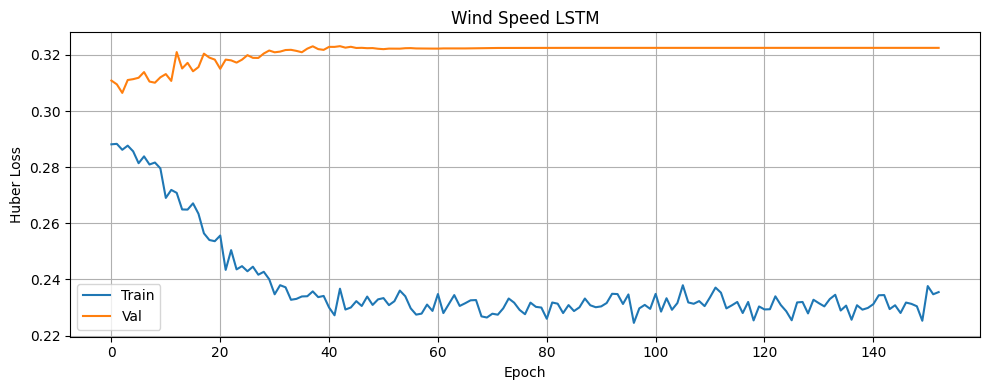

In [12]:
plt.figure(figsize=(10, 4))
plt.plot(history['train'], label='Train')
plt.plot(history['val'],   label='Val')
plt.xlabel('Epoch'); plt.ylabel('Huber Loss')
plt.title('Wind Speed LSTM')
plt.legend(); plt.grid(True)
plt.tight_layout(); plt.show()

In [13]:
model.eval()
preds, trues = [], []
with torch.no_grad():
    for xb, yb in te_loader:
        preds.extend(model(xb.to(device)).cpu().numpy())
        trues.extend(yb.numpy())

preds_ms = scaler_y.inverse_transform(np.array(preds).reshape(-1,1)).ravel()
trues_ms = scaler_y.inverse_transform(np.array(trues).reshape(-1,1)).ravel()

rmse = np.sqrt(mean_squared_error(trues_ms, preds_ms))
mae  = mean_absolute_error(trues_ms, preds_ms)
r2   = r2_score(trues_ms, preds_ms)
print(f"RMSE={rmse:.4f} m/s | MAE={mae:.4f} m/s | R²={r2:.4f}")

RMSE=1.2332 m/s | MAE=0.9961 m/s | R²=0.0074


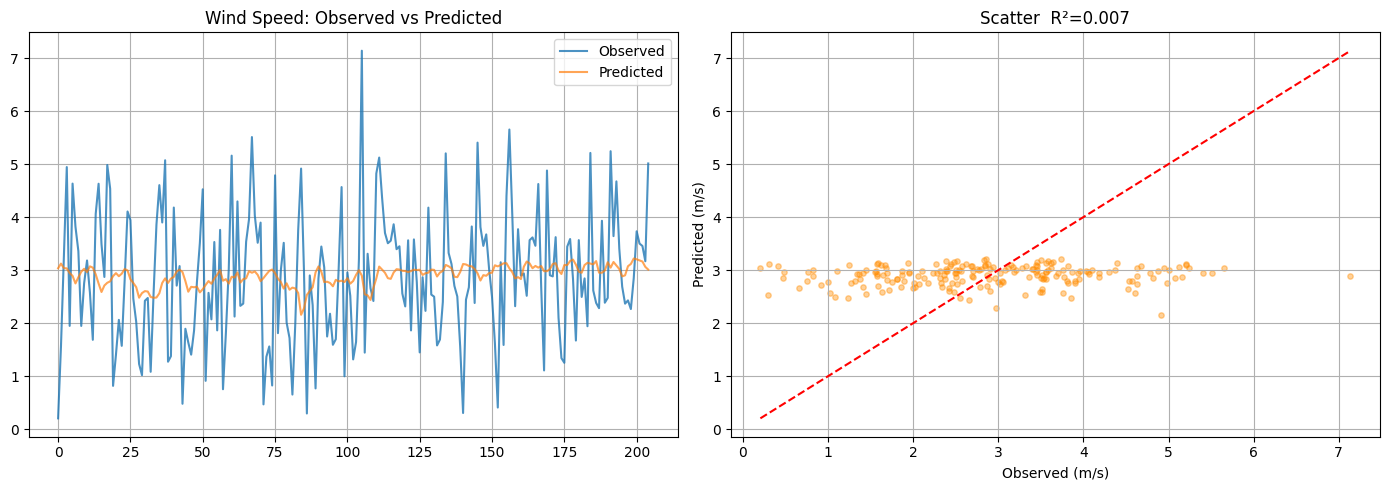

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(trues_ms, label='Observed', alpha=0.8)
axes[0].plot(preds_ms, label='Predicted', alpha=0.7)
axes[0].set_title('Wind Speed: Observed vs Predicted'); axes[0].legend(); axes[0].grid(True)

axes[1].scatter(trues_ms, preds_ms, alpha=0.4, s=15, c='darkorange')
mn, mx = trues_ms.min(), trues_ms.max()
axes[1].plot([mn,mx],[mn,mx],'r--',lw=1.5); axes[1].set_title(f'Scatter  R²={r2:.3f}')
axes[1].set_xlabel('Observed (m/s)'); axes[1].set_ylabel('Predicted (m/s)'); axes[1].grid(True)
plt.tight_layout(); plt.show()